In [223]:
import pandas as pd
import  numpy as np
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt 
import seaborn as sns 
import datetime as dt
from datetime import datetime

In [224]:
df= pd.read_csv("data.csv")
display(df)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/10 8:26,"2,55",17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/10 8:26,"3,39",17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/10 8:26,"2,75",17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/10 8:26,"3,39",17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/10 8:26,"3,39",17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,12/9/11 12:50,"0,85",12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12/9/11 12:50,"2,1",12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12/9/11 12:50,"4,15",12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12/9/11 12:50,"4,15",12680.0,France


## EDA

In [225]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  str    
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(1), int64(1), str(6)
memory usage: 68.3 MB


In [226]:
df.shape

(541909, 8)

In [227]:
df.head()
df.columns


Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='str')

In [228]:

df.dtypes


InvoiceNo          str
StockCode          str
Description        str
Quantity         int64
InvoiceDate        str
UnitPrice          str
CustomerID     float64
Country            str
dtype: object

In [229]:
df.describe()

,Quantity,CustomerID
count,541909.000000,406829.000000
mean,9.552250,15287.690570
std,218.081158,1713.600303
min,-80995.000000,12346.000000
25%,1.000000,13953.000000
50%,3.000000,15152.000000
75%,10.000000,16791.000000
max,80995.000000,18287.000000


### data preparing

In [230]:
df.isna().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

### convert InvocieNo to float

### traiter  les donness manquantes

In [231]:
df.dropna(subset=['CustomerID'],inplace=True)
df.isna().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

### Analyse CostumerID 

In [232]:
df['CustomerID'].head()
df['CustomerID'].dtype

df['CustomerID'].isna().sum()

df['CustomerID'].nunique()


4372

In [233]:
df['CustomerID'].value_counts().describe()     

count    4372.000000
mean       93.053294
std       232.471608
min         1.000000
25%        17.000000
50%        42.000000
75%       102.000000
max      7983.000000
Name: count, dtype: float64

In [234]:
df['InvoiceDate']=pd.to_datetime(df['InvoiceDate'])
df.dtypes

C:\Users\Youcode\AppData\Local\Temp\ipykernel_18260\2208571527.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['InvoiceDate']=pd.to_datetime(df['InvoiceDate'])


InvoiceNo                 str
StockCode                 str
Description               str
Quantity                int64
InvoiceDate    datetime64[us]
UnitPrice                 str
CustomerID            float64
Country                   str
dtype: object

## traiter les donnees  

In [235]:
df_uniq=df['CustomerID'].isna().sum()
print(df_uniq)
df
df['UnitPrice']=df['UnitPrice'].str.replace(',','.').astype(float)

0


<Axes: xlabel='Country'>

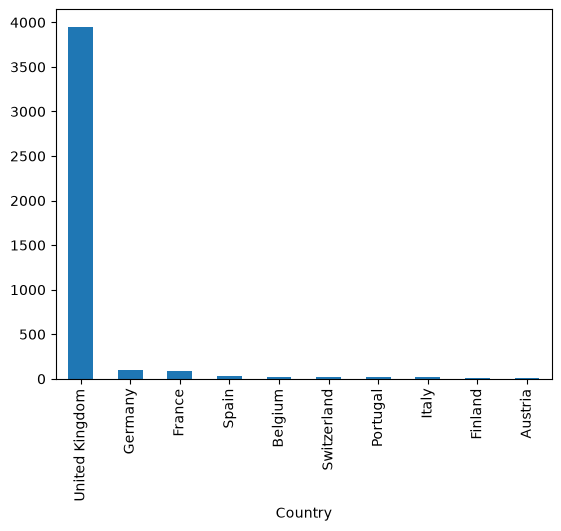

In [236]:
filtered_data=df[['Country','CustomerID']].drop_duplicates()


filtered_data.Country.value_counts()[:10].plot(kind='bar')

### RFM

In [237]:
df_rfm = df.copy()
df_rfm = df_rfm[df_rfm['Quantity'] > 0]
df_rfm = df_rfm[df_rfm['UnitPrice'] > 0]

print(df_rfm.shape)
df_rfm.head()

(397884, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


### Frequency

In [238]:
freq = df_rfm.groupby('CustomerID')['InvoiceNo'].nunique().rename('Frequence')
freq.head()

CustomerID
12346.0    1
12347.0    7
12348.0    4
12349.0    1
12350.0    1
Name: Frequence, dtype: int64

### Recency

In [239]:

Now = df_rfm['InvoiceDate'].max() + pd.Timedelta(days=1)

last_sales = df_rfm.groupby('CustomerID')['InvoiceDate'].max()

recence = (Now - last_sales).dt.days.rename('Recence')
recence.head()

CustomerID
12346.0    326
12347.0      2
12348.0     75
12349.0     19
12350.0    310
Name: Recence, dtype: int64

### Monetary

In [240]:
df_rfm['Total_Price'] = df_rfm['Quantity'] * df_rfm['UnitPrice']

montant = df_rfm.groupby('CustomerID')['Total_Price'].sum().rename('Montant')
montant.head()

CustomerID
12346.0    77183.60
12347.0     4310.00
12348.0     1797.24
12349.0     1757.55
12350.0      334.40
Name: Montant, dtype: float64

In [241]:
rfm = pd.concat([recence, freq, montant], axis=1).reset_index()
rfm.columns = ['CustomerID', 'Recence', 'Frequence', 'Montant']

print(rfm.shape)
print(rfm.isna().sum())
rfm.head()

(4338, 4)
CustomerID    0
Recence       0
Frequence     0
Montant       0
dtype: int64


,CustomerID,Recence,Frequence,Montant
0,12346.0,326,1,77183.60
1,12347.0,2,7,4310.00
2,12348.0,75,4,1797.24
3,12349.0,19,1,1757.55
4,12350.0,310,1,334.40


### des indicateurs RFM
Recence:Nombre de jours depuis le dernier achat du client

frequence : Nombre de commandes distinctes passees par le client

Montery : Somme totale depensee par le client

#### Préparation des variables pour le clustering

In [242]:

rfm[['Recence', 'Frequence', 'Montant']].describe()

,Recence,Frequence,Montant
count,4338.000000,4338.000000,4338.000000
mean,92.536422,4.272015,2054.266460
std,100.014169,7.697998,8989.230441
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,307.415000
50%,51.000000,2.000000,674.485000
75%,142.000000,5.000000,1661.740000
max,374.000000,209.000000,280206.020000


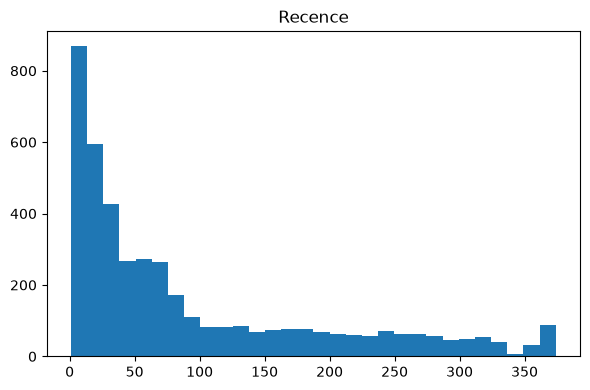

In [243]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(rfm['Recence'], bins=30)
ax.set_title('Recence')
plt.tight_layout()
plt.show()

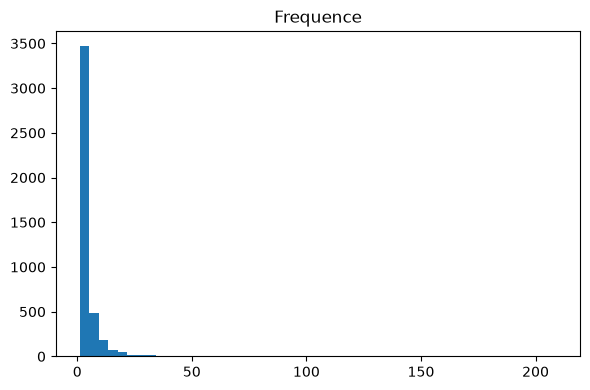

In [244]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(rfm['Frequence'], bins=50)
ax.set_title('Frequence')
plt.tight_layout()
plt.show()

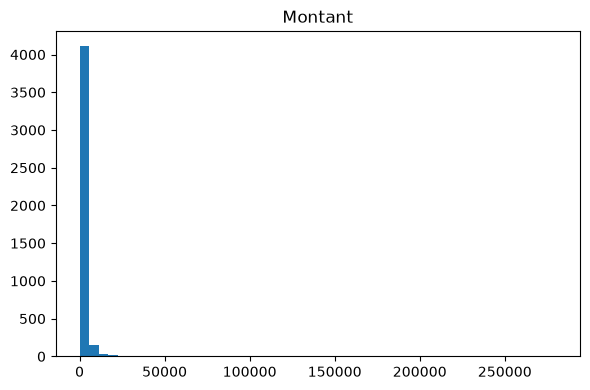

In [245]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(rfm['Montant'], bins=50)
ax.set_title('Montant')
plt.tight_layout()
plt.show()

In [246]:
rfm['Recence'] = np.log1p(rfm['Recence'])
rfm['Frequence'] = np.log1p(rfm['Frequence'])
rfm['Montant'] = np.log1p(rfm['Montant'])

In [247]:
features = ['Recence', 'Frequence', 'Montant']
X = rfm[features]

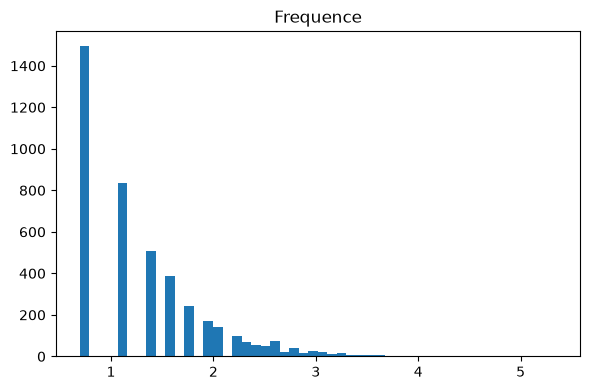

In [248]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(rfm['Frequence'], bins=50)
ax.set_title('Frequence')
plt.tight_layout()
plt.show()